In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from src.models.trainer import (
    build_logistic_regression,
    build_random_forest,
    build_linear_svc,
    train_model,
    save_model
)
from src.models.evaluator import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    save_metrics_report,
    plot_model_comparison
)
from src.utils.config import MODELS_DIR

print("All imports successful")

All imports successful


In [2]:
splits = joblib.load(MODELS_DIR / "train_test_splits.pkl")

X_train_tfidf = splits["X_train_tfidf"]
X_test_tfidf  = splits["X_test_tfidf"]
y_cat_train   = splits["y_cat_train"]
y_cat_test    = splits["y_cat_test"]
CATEGORY_LABELS = sorted(y_cat_train.unique().tolist())

print(f"Training matrix: {X_train_tfidf.shape}")
print(f"Test matrix:     {X_test_tfidf.shape}")
print(f"\nClasses: {CATEGORY_LABELS}")

Training matrix: (1571, 1330)
Test matrix:     (657, 1330)

Classes: ['Active Directory', 'Computer-Services', 'EOL', 'Fileservice', 'O365', 'Software', 'Support general']


In [3]:
lr_model = build_logistic_regression()
lr_model = train_model(lr_model, X_train_tfidf, y_cat_train)

[2026-04-11 11:03:51] INFO — src.models.trainer — Training LogisticRegression...
[2026-04-11 11:03:51] INFO — src.models.trainer — LogisticRegression training complete


[2026-04-11 11:03:51] INFO — src.models.evaluator — Evaluating Logistic Regression...
[2026-04-11 11:03:51] INFO — src.models.evaluator —   Accuracy:  0.726
[2026-04-11 11:03:51] INFO — src.models.evaluator —   Precision: 0.7811
[2026-04-11 11:03:51] INFO — src.models.evaluator —   Recall:    0.726
[2026-04-11 11:03:51] INFO — src.models.evaluator —   F1 Score:  0.7363

=== CLASSIFICATION REPORT — Logistic Regression ===
                   precision    recall  f1-score   support

 Active Directory       0.48      0.55      0.51        49
Computer-Services       0.58      0.61      0.60        41
              EOL       1.00      1.00      1.00        58
      Fileservice       0.99      0.85      0.91       138
             O365       0.50      0.88      0.64        92
         Software       0.49      0.57      0.52        58
  Support general       0.89      0.62      0.73       221

         accuracy                           0.73       657
        macro avg       0.70      0.72    

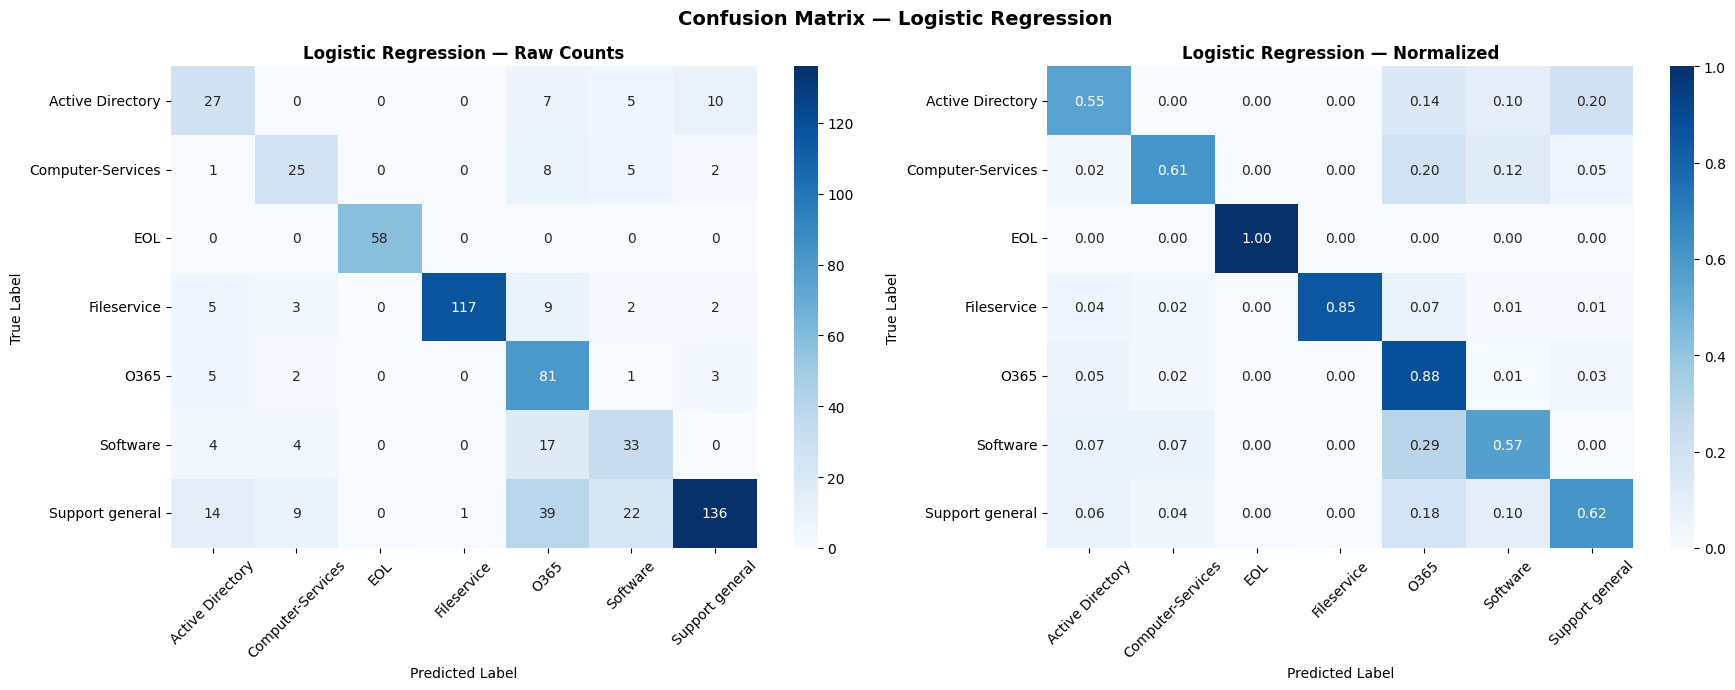

[2026-04-11 11:03:54] INFO — src.models.evaluator — Confusion matrix saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\confusion_matrix_lr.png


In [4]:
lr_metrics, lr_preds = evaluate_model(
    lr_model, X_test_tfidf, y_cat_test, "Logistic Regression"
)

print_classification_report(y_cat_test, lr_preds, "Logistic Regression")

plot_confusion_matrix(
    y_cat_test, lr_preds,
    "Logistic Regression",
    CATEGORY_LABELS,
    "confusion_matrix_lr.png"
)

In [5]:
rf_model = build_random_forest()
rf_model = train_model(rf_model, X_train_tfidf, y_cat_train)

[2026-04-11 11:03:54] INFO — src.models.trainer — Training RandomForestClassifier...
[2026-04-11 11:03:55] INFO — src.models.trainer — RandomForestClassifier training complete


[2026-04-11 11:03:55] INFO — src.models.evaluator — Evaluating Random Forest...
[2026-04-11 11:03:55] INFO — src.models.evaluator —   Accuracy:  0.7412
[2026-04-11 11:03:55] INFO — src.models.evaluator —   Precision: 0.7448
[2026-04-11 11:03:55] INFO — src.models.evaluator —   Recall:    0.7412
[2026-04-11 11:03:55] INFO — src.models.evaluator —   F1 Score:  0.739

=== CLASSIFICATION REPORT — Random Forest ===
                   precision    recall  f1-score   support

 Active Directory       0.58      0.43      0.49        49
Computer-Services       0.72      0.56      0.63        41
              EOL       1.00      1.00      1.00        58
      Fileservice       0.98      0.87      0.92       138
             O365       0.58      0.70      0.63        92
         Software       0.40      0.34      0.37        58
  Support general       0.73      0.82      0.77       221

         accuracy                           0.74       657
        macro avg       0.71      0.67      0.69     

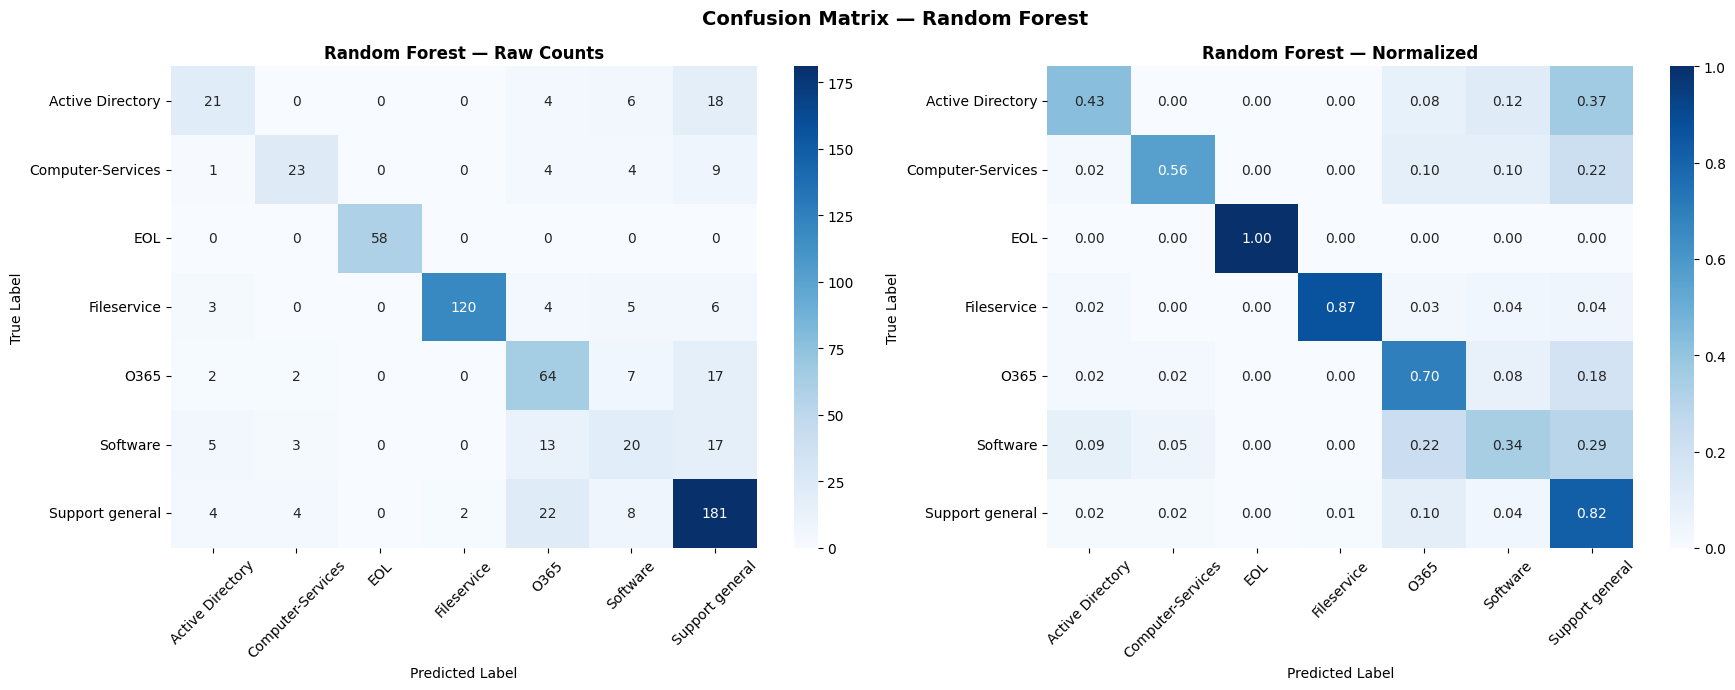

[2026-04-11 11:03:57] INFO — src.models.evaluator — Confusion matrix saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\confusion_matrix_rf.png


In [6]:
rf_metrics, rf_preds = evaluate_model(
    rf_model, X_test_tfidf, y_cat_test, "Random Forest"
)

print_classification_report(y_cat_test, rf_preds, "Random Forest")

plot_confusion_matrix(
    y_cat_test, rf_preds,
    "Random Forest",
    CATEGORY_LABELS,
    "confusion_matrix_rf.png"
)

In [7]:
svc_model = build_linear_svc()
svc_model = train_model(svc_model, X_train_tfidf, y_cat_train)

[2026-04-11 11:03:57] INFO — src.models.trainer — Training LinearSVC...
[2026-04-11 11:03:57] INFO — src.models.trainer — LinearSVC training complete


[2026-04-11 11:03:57] INFO — src.models.evaluator — Evaluating LinearSVC...
[2026-04-11 11:03:57] INFO — src.models.evaluator —   Accuracy:  0.7839
[2026-04-11 11:03:57] INFO — src.models.evaluator —   Precision: 0.7963
[2026-04-11 11:03:57] INFO — src.models.evaluator —   Recall:    0.7839
[2026-04-11 11:03:57] INFO — src.models.evaluator —   F1 Score:  0.7874

=== CLASSIFICATION REPORT — LinearSVC ===
                   precision    recall  f1-score   support

 Active Directory       0.47      0.51      0.49        49
Computer-Services       0.69      0.61      0.65        41
              EOL       1.00      1.00      1.00        58
      Fileservice       0.96      0.92      0.94       138
             O365       0.60      0.78      0.68        92
         Software       0.69      0.66      0.67        58
  Support general       0.84      0.77      0.80       221

         accuracy                           0.78       657
        macro avg       0.75      0.75      0.75       657
 

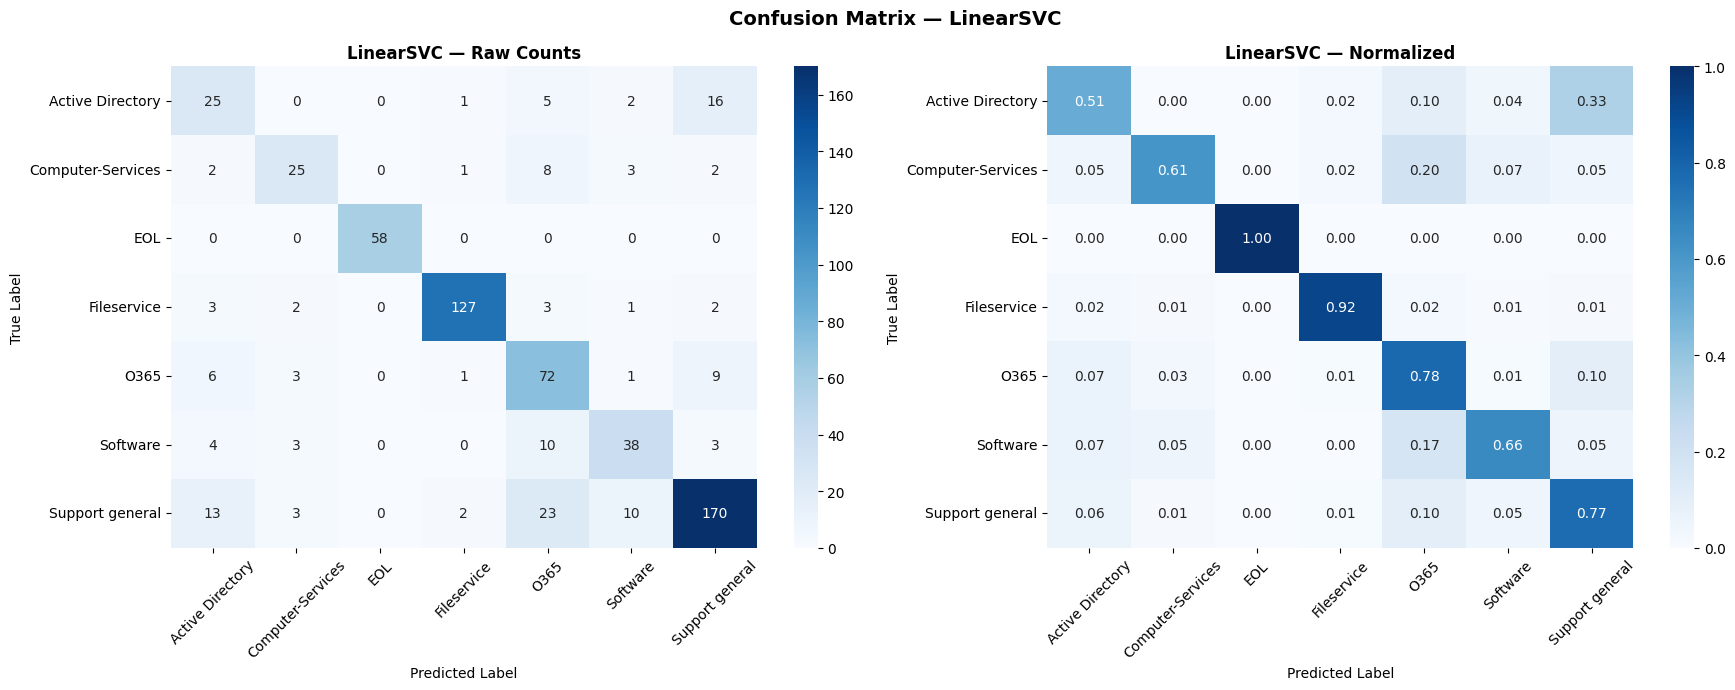

[2026-04-11 11:03:59] INFO — src.models.evaluator — Confusion matrix saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\confusion_matrix_svc.png


In [8]:
svc_metrics, svc_preds = evaluate_model(
    svc_model, X_test_tfidf, y_cat_test, "LinearSVC"
)

print_classification_report(y_cat_test, svc_preds, "LinearSVC")

plot_confusion_matrix(
    y_cat_test, svc_preds,
    "LinearSVC",
    CATEGORY_LABELS,
    "confusion_matrix_svc.png"
)

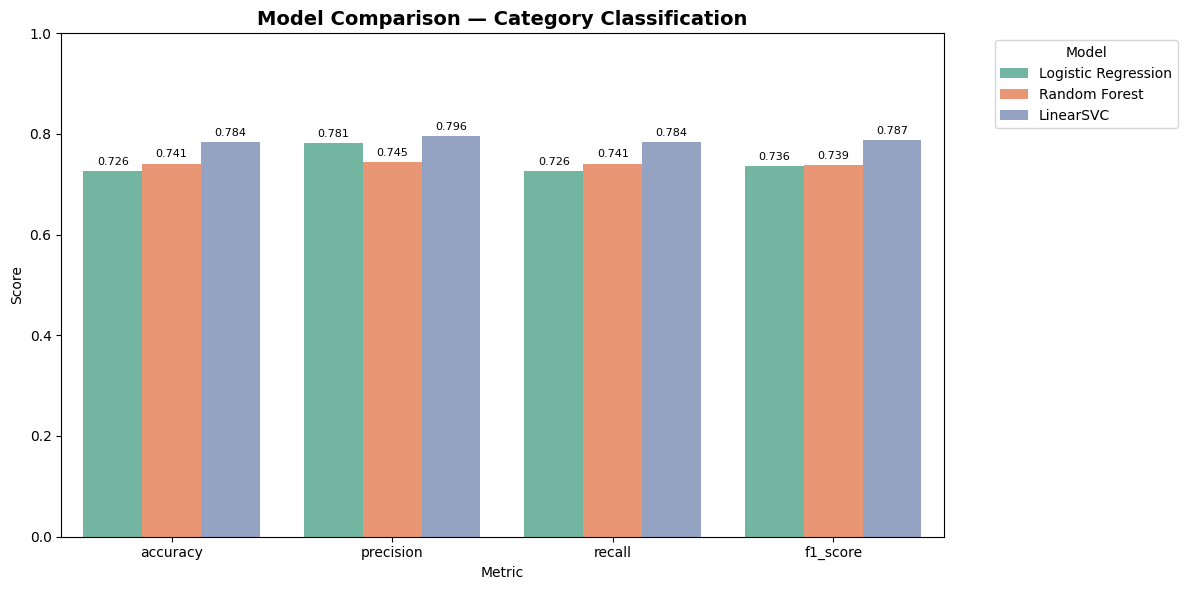

[2026-04-11 11:04:00] INFO — src.models.evaluator — Comparison chart saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\category_model_comparison.png

=== FINAL COMPARISON TABLE ===
              model  accuracy  precision  recall  f1_score
          LinearSVC    0.7839     0.7963  0.7839    0.7874
      Random Forest    0.7412     0.7448  0.7412    0.7390
Logistic Regression    0.7260     0.7811  0.7260    0.7363


In [9]:
all_metrics = [lr_metrics, rf_metrics, svc_metrics]

plot_model_comparison(all_metrics, "category_model_comparison.png")

print("\n=== FINAL COMPARISON TABLE ===")
df_results = pd.DataFrame(all_metrics)
df_results = df_results.sort_values("f1_score", ascending=False)
print(df_results.to_string(index=False))

In [10]:
best = max(all_metrics, key=lambda x: x["f1_score"])
print(f"Best model: {best['model']} with F1={best['f1_score']}")

model_map = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "LinearSVC": svc_model,
}

best_model = model_map[best["model"]]
save_model(best_model, "category_classifier.pkl")
save_metrics_report(all_metrics, "category_metrics.json")

print("\nBest model saved as category_classifier.pkl")

Best model: LinearSVC with F1=0.7874
[2026-04-11 11:04:00] INFO — src.models.trainer — Model saved to E:\Future ml projects\FUTURE_ML_02\outputs\models\category_classifier.pkl
[2026-04-11 11:04:00] INFO — src.models.evaluator — Metrics report saved to E:\Future ml projects\FUTURE_ML_02\outputs\reports\category_metrics.json

Best model saved as category_classifier.pkl


In [11]:
X_test_raw = splits["X_test"]

error_df = pd.DataFrame({
    "text": X_test_raw.values,
    "true": y_cat_test.values,
    "predicted": model_map[best["model"]].predict(X_test_tfidf),
})

errors = error_df[error_df["true"] != error_df["predicted"]]

print(f"Total errors: {len(errors)} out of {len(error_df)} ({len(errors)/len(error_df)*100:.1f}%)")
print("\n=== MOST COMMON CONFUSIONS ===")
confusion_pairs = errors.groupby(["true", "predicted"]).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

print("\n=== SAMPLE MISCLASSIFIED TICKETS ===")
for _, row in errors.head(5).iterrows():
    print(f"\nTrue:      {row['true']}")
    print(f"Predicted: {row['predicted']}")
    print(f"Text:      {str(row['text'])[:200]}")

Total errors: 142 out of 657 (21.6%)

=== MOST COMMON CONFUSIONS ===
true               predicted       
Support general    O365                23
Active Directory   Support general     16
Support general    Active Directory    13
Software           O365                10
Support general    Software            10
O365               Support general      9
Computer-Services  O365                 8
O365               Active Directory     6
Active Directory   O365                 5
Software           Active Directory     4
dtype: int64

=== SAMPLE MISCLASSIFIED TICKETS ===

True:      Support general
Predicted: Software
Text:      [TICKET ID] - New Support Ticket received  - Setup BB on mobile phone.

True:      Support general
Predicted: Computer-Services
Text:      reserva DHCPPoderia fazer uma reserva no DHCP? [LOCATION][MAC_ADDRESS]  é uma impressora.

True:      Support general
Predicted: O365
Text:      [TICKET ID] - New Support Ticket received  - desk phone not working properly for 